In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


# Pima Indians Diabetes CatBoost 분류

## 개요
- CatBoost Classifier로 당뇨병 예측
- Gradient Boosting의 개선된 알고리즘
- 범주형 변수 자동 처리 및 과적합 방지

## 주요 단계
1. 데이터 로드 및 분리
2. CatBoost 설정
3. GridSearchCV 최적화
4. 성능 평가 및 피처 중요도

## 라이브러리 임포트

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류

In [ ]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64


**데이터 샘플 확인**

In [ ]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.

**학습/테스트 데이터 분리**

In [ ]:
# 데이터 분리 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64


## 2. CatBoost Classifier

**CatBoost vs XGBoost**
- 범주형 변수: 자동 처리 (One-Hot 불필요)
- Ordered Boosting: 과적합 방지
- 대칭 트리: 균형잡힌 트리 구조
- 결측치: 자동 처리
- 기본 성능: 튜닝 없이도 우수

**핵심 개선사항**
- Ordered TS: Target Statistics 누수 방지
- Oblivious Trees: 빠른 예측
- Minimal Variance Sampling: 더 나은 일반화
- Robust to overfitting: 내장 정규화

**하이퍼파라미터**
- iterations: 트리 개수 (n_estimators)
- learning_rate: 학습률
- depth: 트리 깊이 (max_depth)
- l2_leaf_reg: L2 정규화
- border_count: 수치형 특성 분할 수
- bagging_temperature: 베이지안 부트스트랩

## 3. 기본 CatBoost 학습

In [ ]:
# 기본 모델 생성
cat_clf = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0  # 학습 로그 비활성화
)

# 학습
cat_clf.fit(X_train, y_train)

# 예측
y_pred = cat_clf.predict(X_test)

# 평가
train_acc = cat_clf.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)

print("="*50)
print("기본 CatBoost Classifier 결과")
print("="*50)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\n분류 리포트:\n{classification_report(y_test, y_pred)}")

기본 CatBoost Classifier 결과
Train Accuracy: 0.8664
Test Accuracy: 0.7532

분류 리포트:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



## 4. GridSearchCV 하이퍼파라미터 최적화

**탐색할 파라미터**
- iterations: [100, 150, 200]
- learning_rate: [0.01, 0.05, 0.1]
- depth: [4, 6, 8]
- l2_leaf_reg: [1, 3, 5]

**교차 검증**
- StratifiedKFold (3-fold)
- 클래스 비율 유지

In [ ]:
# 하이퍼파라미터 그리드 정의
param_grid = {
    'iterations': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

print("파라미터 그리드:")
for key, value in param_grid.items():
    print(f"  {key}: {value}")

# 총 조합 수
total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\n총 파라미터 조합: {total_combinations}개")

파라미터 그리드:
  iterations: [100, 150, 200]
  learning_rate: [0.01, 0.05, 0.1]
  depth: [4, 6, 8]
  l2_leaf_reg: [1, 3, 5]

총 파라미터 조합: 81개


In [ ]:
# StratifiedKFold 설정
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearchCV 생성
grid_clf = GridSearchCV(
    estimator=CatBoostClassifier(random_state=42, verbose=0),
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV 생성완료...\n")

GridSearchCV 시작...



In [ ]:

grid_clf.fit(X_train, y_train)

Fitting 3 folds for each of 81 candidates, totalling 243 fits


## 5. 최적 모델 결과

In [ ]:
# 최적 파라미터 출력
print("="*50)
print("최적 하이퍼파라미터")
print("="*50)
for param, value in grid_clf.best_params_.items():
    print(f"{param:20s}: {value}")

print(f"\n최적 CV Score: {grid_clf.best_score_:.4f}")

최적 하이퍼파라미터
depth               : 4
iterations          : 100
l2_leaf_reg         : 3
learning_rate       : 0.1

최적 CV Score: 0.7834


In [ ]:
# 최적 모델 저장
best_clf = grid_clf.best_estimator_

# 테스트 데이터 예측
y_pred_best = best_clf.predict(X_test)

# 성능 평가
train_acc_best = best_clf.score(X_train, y_train)
test_acc_best = accuracy_score(y_test, y_pred_best)

print("="*50)
print("최적화된 CatBoost 결과")
print("="*50)
print(f"Train Accuracy: {train_acc_best:.4f}")
print(f"Test Accuracy: {test_acc_best:.4f}")
print(f"\n분류 리포트:\n{classification_report(y_test, y_pred_best)}")

최적화된 CatBoost 결과
Train Accuracy: 0.8225
Test Accuracy: 0.7532

분류 리포트:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



## 6. 성능 비교


성능 비교:
           Model  Train Acc  Test Acc
Default CatBoost   0.866450  0.753247
  Tuned CatBoost   0.822476  0.753247


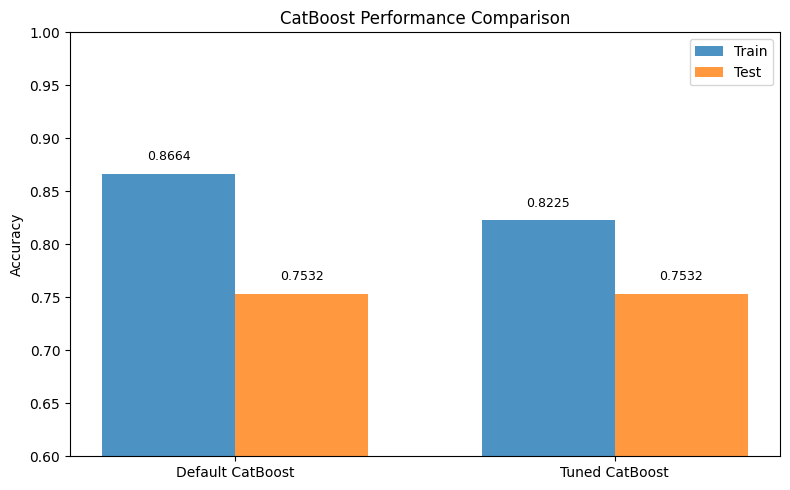

In [ ]:
# 성능 비교 데이터프레임
comparison = pd.DataFrame({
    'Model': ['Default CatBoost', 'Tuned CatBoost'],
    'Train Acc': [train_acc, train_acc_best],
    'Test Acc': [test_acc, test_acc_best]
})

print("\n성능 비교:")
print(comparison.to_string(index=False))

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison['Train Acc'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, comparison['Test Acc'], width, label='Test', alpha=0.8)

ax.set_ylabel('Accuracy')
ax.set_title('CatBoost Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.set_ylim([0.6, 1.0])

# 값 표시
for i, v in enumerate(comparison['Train Acc']):
    ax.text(i - width/2, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(comparison['Test Acc']):
    ax.text(i + width/2, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. 피처 중요도 분석

**CatBoost 피처 중요도 타입**
- PredictionValuesChange (기본)
- LossFunctionChange
- FeatureImportance


피처 중요도 순위:
Feature  Importance
   plas   41.638948
   mass   17.486658
    age   14.104238
   pedi   10.203579
   preg    5.995526
   skin    3.602890
   pres    3.586474
   insu    3.381687


/tmp/ipython-input-1897186079.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


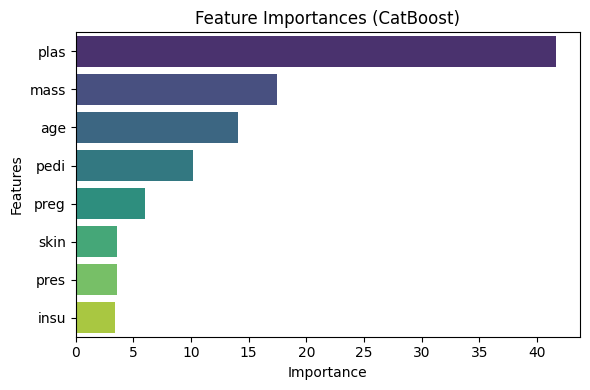

In [ ]:
# 피처 중요도 추출
importances = best_clf.get_feature_importance()
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 8. Early Stopping

**Early Stopping 장점**
- 과적합 방지
- 학습 시간 단축
- 최적 트리 개수 자동 선택

In [ ]:
# Early Stopping with eval_set
cat_early = CatBoostClassifier(
    **grid_clf.best_params_,
    early_stopping_rounds=10,
    random_state=42,
    verbose=0
)

# Validation set 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 학습 (eval_set 제공)
cat_early.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    verbose=False
)

print(f"\nEarly Stopping:")
print(f"최적 트리 개수: {cat_early.get_best_iteration() + 1}")
print(f"설정 트리 개수: {grid_clf.best_params_['iterations']}")
print(f"Test Accuracy: {cat_early.score(X_test, y_test):.4f}")


Early Stopping:
최적 트리 개수: 58
설정 트리 개수: 100
Test Accuracy: 0.7338


## 9. 최종 요약
**성능 결과**
- 기본 모델도 경쟁력 있는 성능
- GridSearch로 추가 성능 향상
- Early Stopping으로 효율적 학습

In [ ]:
print("\n" + "="*50)
print("CatBoost Classification 완료")
print("="*50)

print(f"\n최종 성능:")
print(f"  - 기본 모델 정확도: {test_acc:.4f}")
print(f"  - 최적화 모델 정확도: {test_acc_best:.4f}")
print(f"  - 성능 향상: {(test_acc_best - test_acc)*100:+.2f}%p")

print(f"\n최적 파라미터:")
for param, value in grid_clf.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nTop 3 중요 피처:")
for i in range(min(3, len(importance_df))):
    print(f"  {i+1}. {importance_df.iloc[i]['Feature']}: {importance_df.iloc[i]['Importance']:.4f}")

print("\n" + "="*50)


CatBoost Classification 완료

최종 성능:
  - 기본 모델 정확도: 0.7532
  - 최적화 모델 정확도: 0.7532
  - 성능 향상: +0.00%p

최적 파라미터:
  - depth: 4
  - iterations: 100
  - l2_leaf_reg: 3
  - learning_rate: 0.1

Top 3 중요 피처:
  1. plas: 41.6389
  2. mass: 17.4867
  3. age: 14.1042



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/머신러닝_심화_소스코드_2차

[Errno 2] No such file or directory: '/content/drive/MyDrive/머신러닝_심화_소스코드_2차'
/content


In [4]:
!unzip -qq '/content/drive/MyDrive/실습과제/머신러닝_심화_소스코드_2차.zip'